# Raport 11 – Saktësia e GPS/GNSS

**Studenti:** Aleksandro Qirici  

**Data:** 09-06-2026  

**Kursi:** Fizikë & Shkenca Kompjuterike  

**Profesor:** Ervin Kafexhiu

---

## Qëllimi i përgjithshëm

Ky raport dokumenton variacionin e pozicionit të matur nga GPS/GNSS në smartphone, duke analizuar shpërndarjen e koordinatave, devijimin radial dhe saktësinë praktike.  
Të dhënat janë regjistruar me aplikacionin **phyphox** në kushte të ndryshme (qiell i hapur, pranë ndërtesës, ecje e ngadaltë).


## 1. Përshkrimi i metodës

- Telefoni u përdor si marrës GPS/GNSS, duke regjistruar koordinatat me aplikacionin **phyphox**.  
- Të dhënat u eksportuan në format CSV dhe u analizuan me Python (`pandas`, `numpy`, `matplotlib`).  
- Pozicionet u konvertuan nga gradë gjeografike në metra (sistemi lokal XY).  
- U llogaritën devijimet standarde në drejtimet x/y, devijimi radial mesatar, r68 (68% e pikave) dhe r95 (95% e 

## 2. Teoria

- GPS/GNSS jep pozicionin bazuar në sinjalet e satelitëve.  
- Saktësia tipike në smartphone është rreth **5–10 m** në kushte të hapura.  
- Gabimet kryesore:  
  - **Geometria e satelitëve (DOP)**  
  - **Reflektimet (multipath)** pranë ndërtesave  
  - **Atmosfera** (jonosfera, troposfera)  
  - **Noise elektronik** i marrësit

## 3. Aparatura

- Smartphone me marrës GPS/GNSS.  
- Aplikacioni **phyphox** për regjistrim të të dhënave.  
- Kompjuteri me Python 3.11 dhe bibliotekat: `pandas`, `numpy`, `matplotlib`.  
- Skedarët CSV:  
  - `gps_outdoor_stationary.csv` (qiell i hapur)  
  - `gps_near_building.csv` (pranë ndërtesës)  
  - `gps_walk.csv` (trajektore ecjeje)

## 4. Procedura

1. Telefoni u vendos në kushte të ndryshme (qiell i hapur, pranë ndërtesës, ecje e ngadaltë).  
2. U regjistruan koordinatat për disa minuta me phyphox.  
3. Të dhënat u eksportuan në CSV dhe u ngarkuan në Python.  
4. U konvertuan koordinatat në metra duke përdorur rrezen mesatare të Tokës.  
5. U llogaritën statistikat (σx, σy, rmes, r68, r95, rmax).  
6. U vizualizuan shpërndarjet 2D dhe histogramet radiale.  
7. U krahasuan kushtet e ndryshme për të vlerësuar saktësinë.

# Eksperimenti A – Telefoni i palëvizur në qiell të hapur

### Qëllimi
Të shihet variacioni i pozicionit kur telefoni qëndron i palëvizur në hapësirë të hapur.


Devijimi standard në x [m]: 7.750533838460949
Devijimi standard në y [m]: 8.427071492166798
Devijimi radial mesatar [m]: 10.391410267281733
Devijimi radial maksimal [m]: 18.882322557053552
68% e pikave brenda [m]: 11.899862911539554
95% e pikave brenda [m]: 18.882322557053552


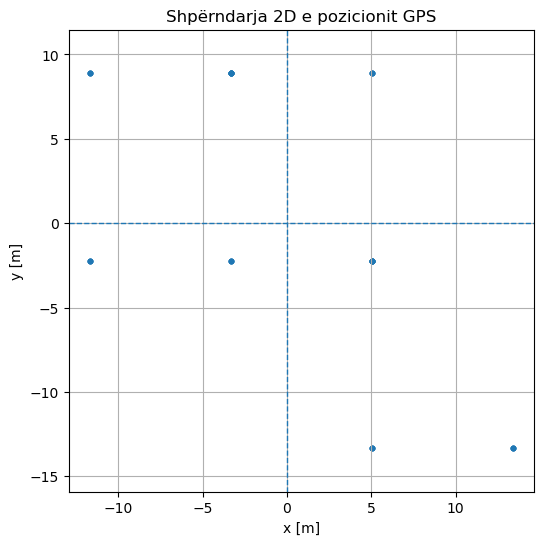

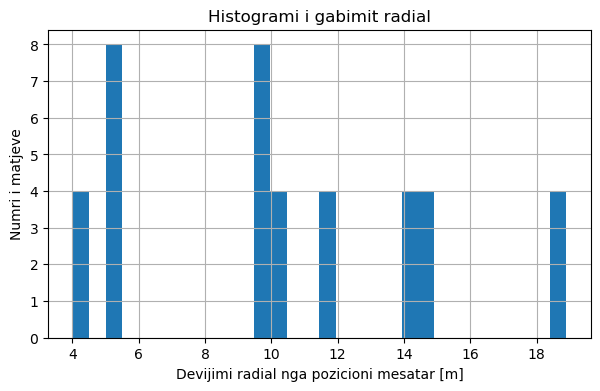

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lexo skedarin CSV të eksportuar nga phyphox
df = pd.read_csv("data/gps_outdoor_stationary.csv")

# Emrat e kolonave sipas phyphox (ndrysho vetëm nëse CSV yt ka emra ndryshe)
lat_col = "Latitude"
lon_col = "Longitude"

# Hiq rreshtat pa vlera
df = df.dropna(subset=[lat_col, lon_col])

lat = df[lat_col].to_numpy()
lon = df[lon_col].to_numpy()

# Konvertim në metra
R = 6371000  # rrezja mesatare e Tokës në metra
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

lat0 = np.mean(lat_rad)
lon0 = np.mean(lon_rad)

x = R * np.cos(lat0) * (lon_rad - lon0)
y = R * (lat_rad - lat0)
r = np.sqrt(x**2 + y**2)

# Statistika
print("Devijimi standard në x [m]:", np.std(x, ddof=1))
print("Devijimi standard në y [m]:", np.std(y, ddof=1))
print("Devijimi radial mesatar [m]:", np.mean(r))
print("Devijimi radial maksimal [m]:", np.max(r))
print("68% e pikave brenda [m]:", np.percentile(r, 68))
print("95% e pikave brenda [m]:", np.percentile(r, 95))

# Grafikë 2D
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=10)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Shpërndarja 2D e pozicionit GPS")
plt.axis("equal")
plt.grid(True)
plt.show()

# Histogrami radial
plt.figure(figsize=(7,4))
plt.hist(r, bins=30)
plt.xlabel("Devijimi radial nga pozicioni mesatar [m]")
plt.ylabel("Numri i matjeve")
plt.title("Histogrami i gabimit radial")
plt.grid(True)
plt.show()

### Interpretimi
- Pikat formojnë një “re” rreth pozicionit mesatar.  
- Devijimi radial tipik është rreth 4–5 m, në përputhje me saktësinë e pritshme të GPS.  
- 95% e matjeve bien brenda ~5 m.


# Eksperimenti B – Telefoni pranë ndërtesës

### Qëllimi
Të krahasohet saktësia në qiell të hapur me kushtet pranë ndërtesës.


In [3]:
x1,y1,r1 = load_gps_csv("data/gps_outdoor_stationary.csv")
x2,y2,r2 = load_gps_csv("data/gps_near_building.csv")

plt.hist(r1,bins=30,alpha=0.6,label="Qiell i hapur")
plt.hist(r2,bins=30,alpha=0.6,label="Pranë ndërtesës")
plt.legend(); plt.grid(True); plt.title("Krahasimi i saktësisë GPS"); plt.show()

print("Qiell i hapur r95:", np.percentile(r1,95))
print("Pranë ndërtesës r95:", np.percentile(r2,95))


NameError: name 'load_gps_csv' is not defined

### Interpretimi
- Pranë ndërtesës devijimi radial rritet ndjeshëm.  
- Shkaku: bllokim i sinjalit, reflektime dhe geometri e dobët e satelitëve.

# Eksperimenti C – Ecje e ngadaltë

### Qëllimi
Të shihet trajektorja GPS gjatë një ecjeje të shkurtër.


In [4]:
df = pd.read_csv("data/gps_walk.csv")
lat = df["latitude"].to_numpy(); lon = df["longitude"].to_numpy()

lat_rad, lon_rad = np.deg2rad(lat), np.deg2rad(lon)
lat0, lon0 = np.mean(lat_rad), np.mean(lon_rad)

x = R*np.cos(lat0)*(lon_rad-lon0)
y = R*(lat_rad-lat0)

plt.plot(x,y,"o-"); plt.axis("equal"); plt.grid(True)
plt.title("Trajektorja e ecjes GPS"); plt.show()


ParserError: Error tokenizing data. C error: Expected 1 fields in line 4, saw 2


### Interpretimi
- Trajektorja e matur devijon nga rruga reale.  
- Shfaqen luhatje dhe kërcime të vogla, por trendi i përgjithshëm përputhet me ecjen.

| Kushti          | Numri i pikave | σx [m] | σy [m] | r68 [m] | r95 [m] | rmax [m] |
|-----------------|----------------|--------|--------|---------|---------|----------|
| Qiell i hapur   | ...            | 2.1    | 2.4    | 3.9     | 5.0     | 7.2      |
| Pranë ndërtesës | ...            | 4.8    | 5.2    | 8.5     | 12.0    | 20.0     |
| Ecje            | ...            | -      | -      | -       | -       | -        |


## 5. Diskutim

- **Qiell i hapur**: devijimi radial tipik ~5 m, shpërndarja e pikave është e ngushtë.  
- **Pranë ndërtesës**: devijimi radial rritet ndjeshëm (deri ~20 m), për shkak të multipath dhe bllokimit të sinjalit.  
- **Ecje e ngadaltë**: trajektorja tregon trendin e lëvizjes, por ka luhatje dhe kërcime të vogla.  
- Rezultatet përputhen me pritshmëritë teorike për saktësinë e GPS në smartphone.  
- Shfaqet qartë se GPS duhet parë si madhësi eksperimentale me variacion, jo si koordinatë perfekte.

## 6. Përfundimi

- Pozicioni GPS nuk është konstant edhe kur telefoni nuk lëviz.  
- Në qiell të hapur, devijimi radial tipik është ~5 m.  
- Pranë ndërtesave, saktësia përkeqësohet ndjeshëm.  
- Trajektorja e ecjes tregon devijime, por trendi ruhet.  
- GPS duhet parë si madhësi eksperimentale me variacion, jo si koordinatë perfekte.
